# 🏠 Vietnam Housing Market Analysis
### Data Science Project — COMP-140

**Dataset:** Vietnam Housing Dataset (30,229 listings)  
**Goal:** Explore the Vietnamese real estate market, understand what drives property prices, and build predictive models.  
**Hypothesis:** *Property price in Vietnam is primarily driven by physical characteristics (area, number of bathrooms/bedrooms) rather than legal or furnishing status.*


---
## Stage 1: Data Acquisition

The dataset was sourced from a Vietnamese real estate platform and contains **30,229 property listings** with 12 features including address, physical attributes, legal status, furniture state, and price (in billions VND).


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Load data
df = pd.read_csv('vietnam_housing_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


---
## Stage 2: Data Cleaning & Reshaping

Before analysis, we must assess data quality: missing values, data types, and any inconsistencies.


In [31]:
# Data types and basic info
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Missing Values ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

--- Data Types ---
Address               object
Area                 float64
Frontage             float64
Access Road          float64
House direction       object
Balcony direction     object
Floors               float64
Bedrooms             float64
Bathrooms            float64
Legal status          object
Furniture state       object
Price                float64
dtype: object

--- Missing Values ---
                   Missing Count  Missing %
Address                        0        0.0
Area                           0        0.0
Frontage                   11564       38.3
Access Road                13297       44.0
House direction            21239       70.3
Balcony direction          24983       82.6
Floors                      3603       11.9
Bedrooms                    5162       17.1
Bathrooms                   7074       23.4
Legal status                4506       14.9
Furniture state            14119       46.7
Price                          0        0.0


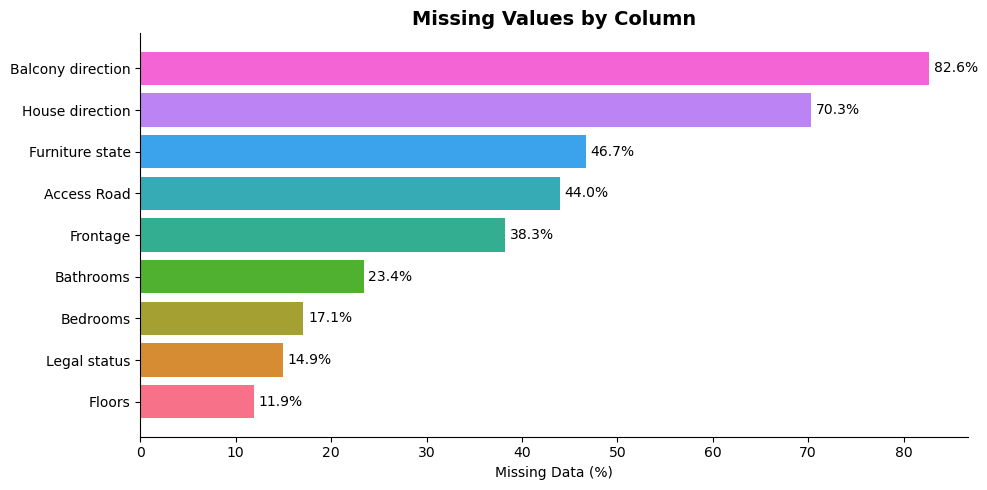

In [33]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(10, 5))
cols = df.columns[df.isnull().any()]
pcts = (df[cols].isnull().mean() * 100).sort_values(ascending=True)
bars = ax.barh(pcts.index, pcts.values, color=sns.color_palette('husl', len(pcts)))
ax.set_xlabel('Missing Data (%)')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
for bar, val in zip(bars, pcts.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.show()

In [35]:
# --- Cleaning Steps ---

# 1. Extract city from address (last component after final comma)
df['City'] = df['Address'].str.extract(r',\s*([^,]+)\s*$')

# 2. Normalize city names (strip trailing dots/spaces)
df['City'] = df['City'].str.strip().str.rstrip('.')

# 3. Unify common city variants
city_map = {
    'TpHCM': 'Hồ Chí Minh', 'TP. HCM': 'Hồ Chí Minh',
    'Hà Nội.': 'Hà Nội', 'Hải Phòng.': 'Hải Phòng'
}
df['City'] = df['City'].replace(city_map)

# 4. Remove extreme price outliers (>99th percentile)
p99 = df['Price'].quantile(0.99)
df_clean = df[df['Price'] <= p99].copy()

print(f'Rows after outlier removal: {len(df_clean)} (removed {len(df) - len(df_clean)} outliers)')
print(f'Cities extracted: {df_clean["City"].nunique()} unique cities')
print(f'\nTop 10 cities by listing count:')
print(df_clean['City'].value_counts().head(10))

Rows after outlier removal: 30219 (removed 10 outliers)
Cities extracted: 72 unique cities

Top 10 cities by listing count:
City
Hồ Chí Minh        11780
Hà Nội             10450
Bình Dương          1672
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            743
Hưng Yên             403
Long An              339
Bà Rịa Vũng Tàu      240
Name: count, dtype: int64


---
## Stage 3: Exploratory Data Analysis (EDA)

We explore distributions, relationships, and patterns in the cleaned dataset.


In [38]:
# Statistical summary
df_clean[['Area','Frontage','Floors','Bedrooms','Bathrooms','Price']].describe().round(2)

,Area,Frontage,Floors,Bedrooms,Bathrooms,Price
count,30219.00,18658.00,26618.00,25059.00,23147.00,30219.00
mean,68.50,5.36,3.41,3.51,3.35,5.87
std,48.08,4.35,1.33,1.31,1.40,2.21
min,3.10,1.00,1.00,1.00,1.00,1.00
25%,40.00,4.00,2.00,3.00,2.00,4.20
50%,56.00,4.50,3.00,3.00,3.00,5.90
75%,80.00,5.00,4.00,4.00,4.00,7.50
max,595.00,77.00,10.00,9.00,9.00,10.00


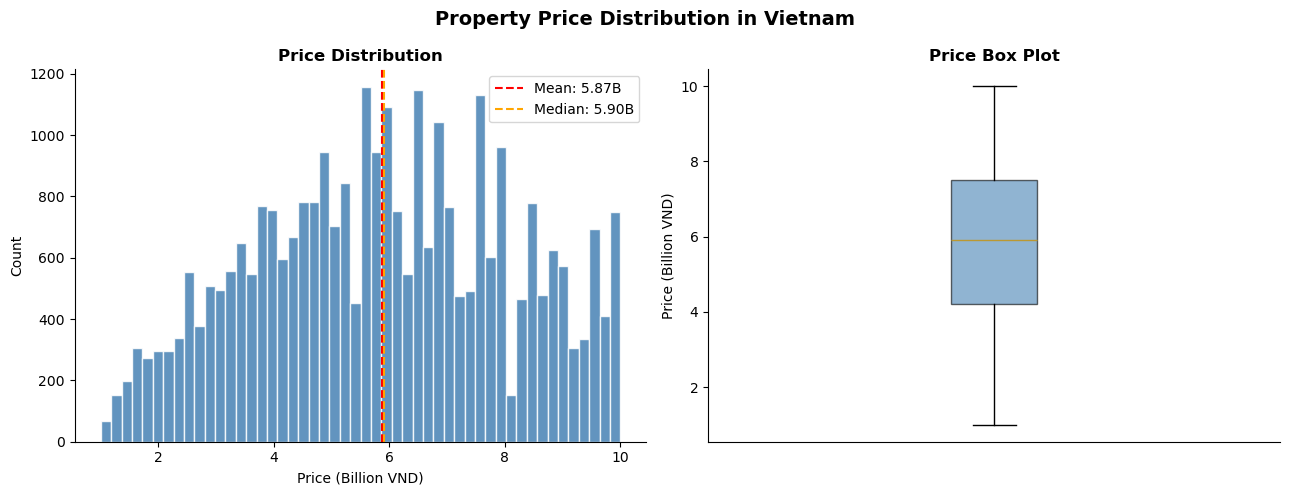

Skewness: -0.030 (positive skew — most listings are lower-priced)


In [40]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(df_clean['Price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['Price'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Price'].mean():.2f}B")
axes[0].axvline(df_clean['Price'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['Price'].median():.2f}B")
axes[0].set_xlabel('Price (Billion VND)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(df_clean['Price'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Price (Billion VND)')
axes[1].set_title('Price Box Plot', fontweight='bold')
axes[1].set_xticks([])

plt.suptitle('Property Price Distribution in Vietnam', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Skewness: {df_clean["Price"].skew():.3f} (positive skew — most listings are lower-priced)')

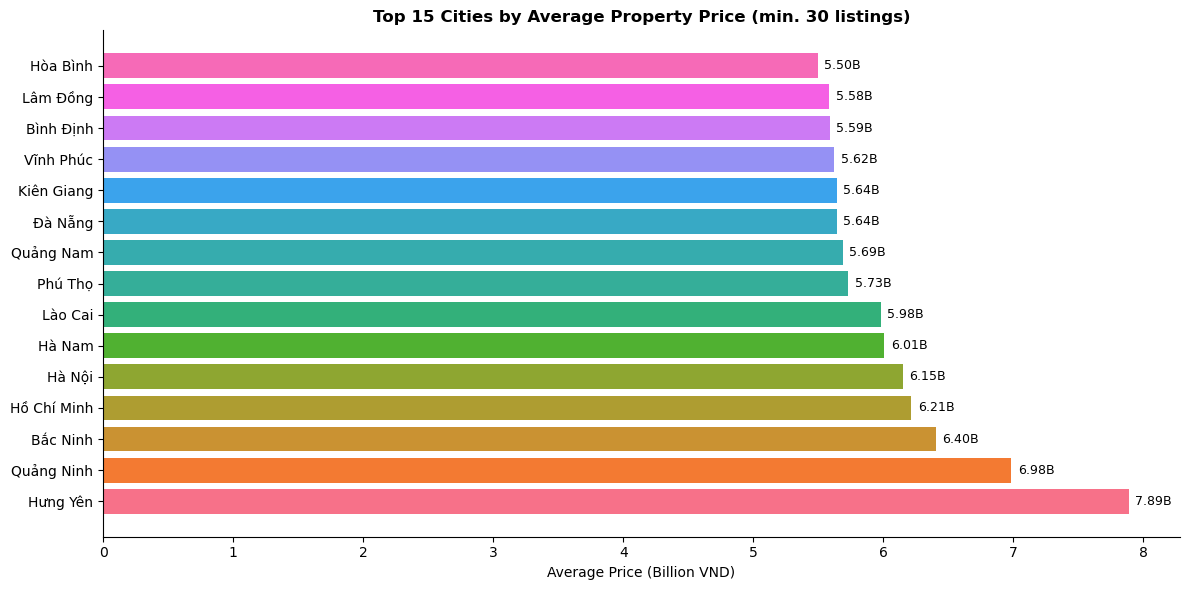

In [42]:
# Top cities by average price
city_stats = df_clean.groupby('City').agg(
    Count=('Price','count'),
    Avg_Price=('Price','mean')
).query('Count >= 30').sort_values('Avg_Price', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('husl', len(city_stats))
bars = ax.barh(city_stats.index, city_stats['Avg_Price'], color=colors)
ax.set_xlabel('Average Price (Billion VND)')
ax.set_title('Top 15 Cities by Average Property Price (min. 30 listings)', fontweight='bold')
for bar, val in zip(bars, city_stats['Avg_Price']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}B', va='center', fontsize=9)
plt.tight_layout()
plt.show()

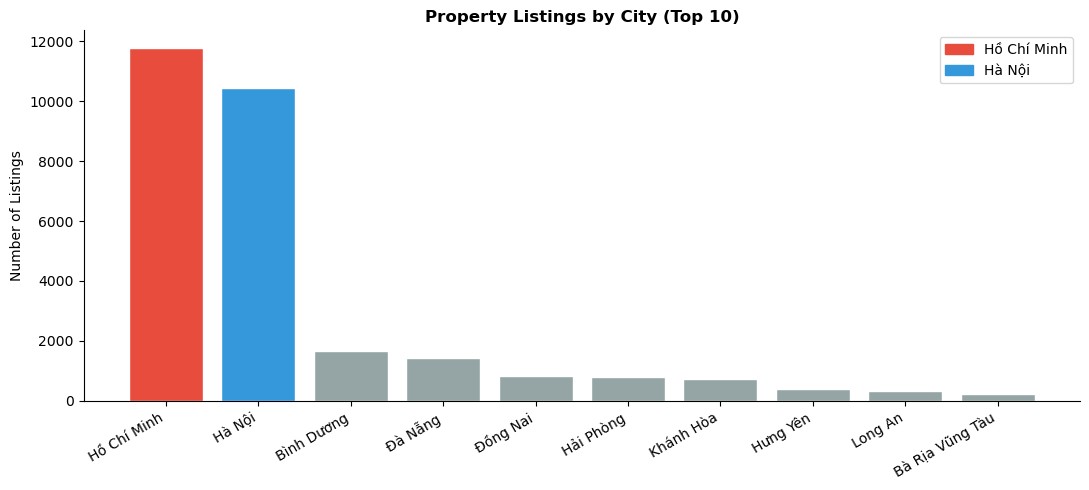

In [44]:
# Listings count: Ho Chi Minh vs Ha Noi vs rest
city_counts = df_clean['City'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
palette = ['#e74c3c' if c == 'Hồ Chí Minh' else '#3498db' if c == 'Hà Nội' else '#95a5a6' for c in city_counts.index]
ax.bar(city_counts.index, city_counts.values, color=palette, edgecolor='white')
ax.set_ylabel('Number of Listings')
ax.set_title('Property Listings by City (Top 10)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
red_patch = mpatches.Patch(color='#e74c3c', label='Hồ Chí Minh')
blue_patch = mpatches.Patch(color='#3498db', label='Hà Nội')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

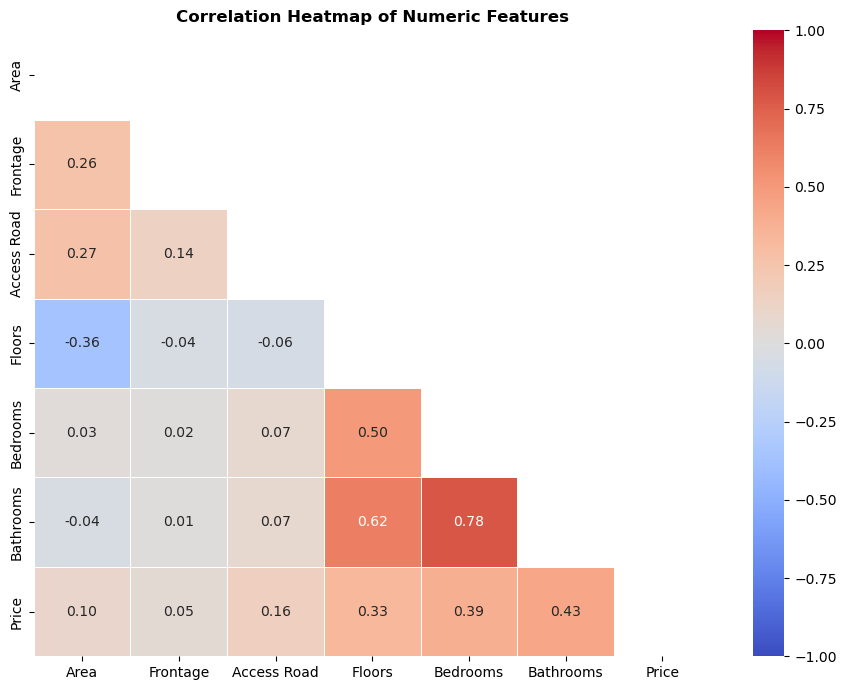


Correlation with Price (sorted):
Bathrooms      0.433973
Bedrooms       0.389538
Floors         0.331169
Access Road    0.163801
Area           0.097732
Frontage       0.047688
Name: Price, dtype: float64


In [46]:
# Correlation heatmap
num_cols = ['Area','Frontage','Access Road','Floors','Bedrooms','Bathrooms','Price']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()
print('\nCorrelation with Price (sorted):')
print(corr['Price'].drop('Price').sort_values(ascending=False))

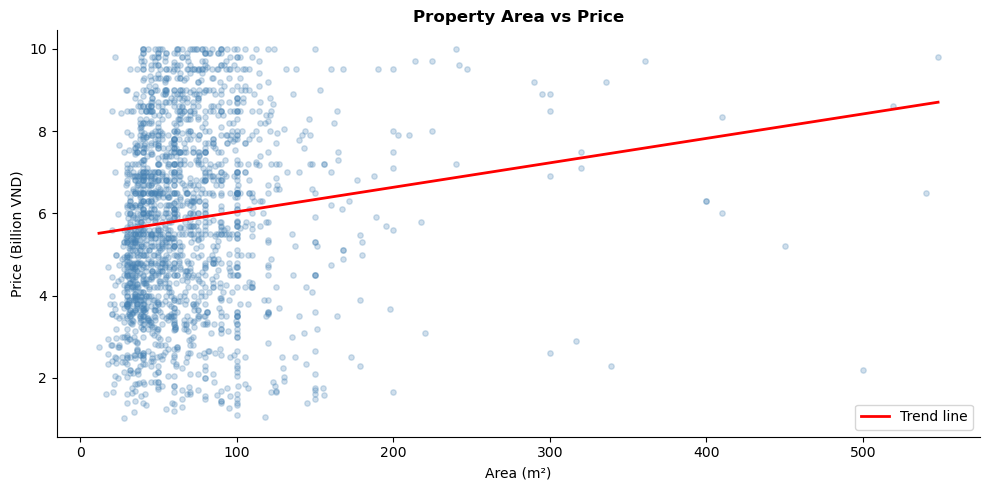

In [48]:
# Scatter: Area vs Price
sample = df_clean[['Area','Price']].dropna().sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['Area'], sample['Price'], alpha=0.25, s=15, color='steelblue')
# Trend line
z = np.polyfit(sample['Area'], sample['Price'], 1)
p = np.poly1d(z)
xs = np.linspace(sample['Area'].min(), sample['Area'].max(), 200)
ax.plot(xs, p(xs), color='red', linewidth=2, label='Trend line')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (Billion VND)')
ax.set_title('Property Area vs Price', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

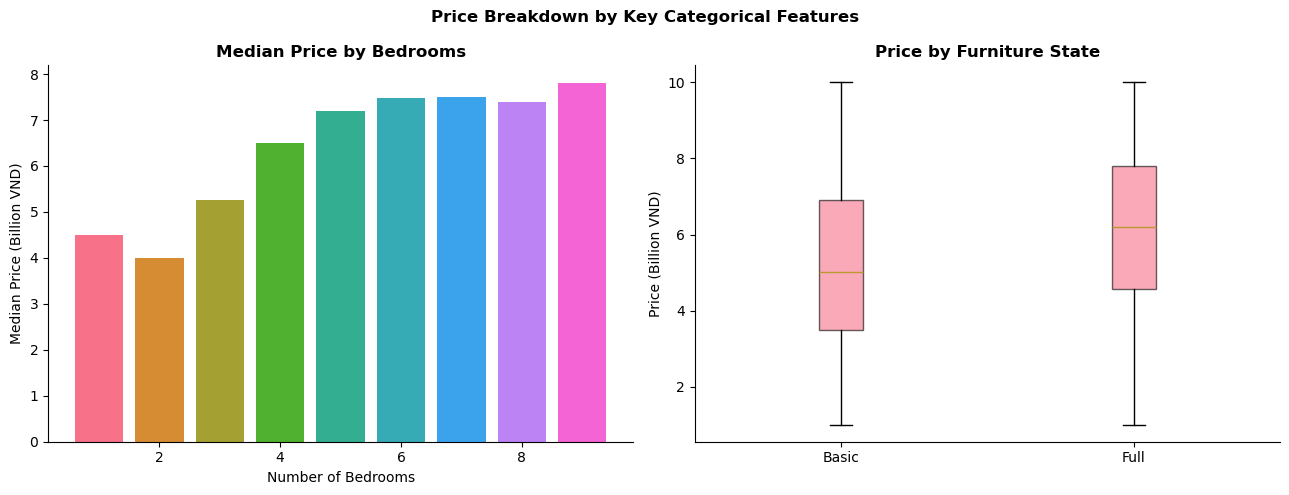

In [50]:
# Price by bedrooms
bed_price = df_clean.groupby('Bedrooms')['Price'].median().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Median price by bedrooms
axes[0].bar(bed_price.index.astype(int), bed_price.values,
            color=sns.color_palette('husl', len(bed_price)))
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Median Price (Billion VND)')
axes[0].set_title('Median Price by Bedrooms', fontweight='bold')

# Price by furniture state
furn = df_clean.groupby('Furniture state')['Price']
data_furn = [furn.get_group(g).dropna().values for g in furn.groups]
axes[1].boxplot(data_furn, labels=list(furn.groups.keys()), patch_artist=True,
                boxprops=dict(alpha=0.6))
axes[1].set_ylabel('Price (Billion VND)')
axes[1].set_title('Price by Furniture State', fontweight='bold')

plt.suptitle('Price Breakdown by Key Categorical Features', fontweight='bold')
plt.tight_layout()
plt.show()

Price stats by Legal Status:
                    count  mean   std  min  25%   50%  75%   max
Legal status                                                    
Have certificate  24766.0  5.86  2.19  1.0  4.2  5.85  7.5  10.0
Sale contract       949.0  5.89  2.41  1.0  4.2  6.10  7.8  10.0


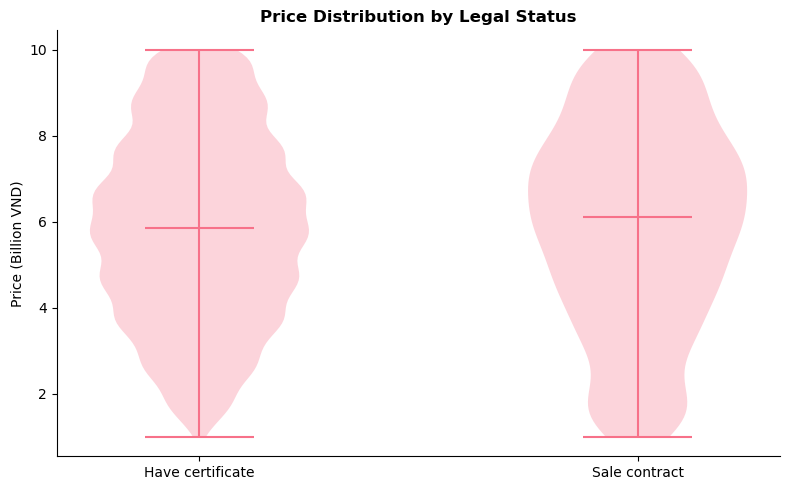

In [52]:
# Price by legal status
legal_stats = df_clean.groupby('Legal status')['Price'].describe().round(2)
print('Price stats by Legal Status:')
print(legal_stats)

fig, ax = plt.subplots(figsize=(8, 5))
legal_groups = [df_clean[df_clean['Legal status'] == s]['Price'].dropna().values
                for s in df_clean['Legal status'].dropna().unique()]
ax.violinplot(legal_groups, showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(df_clean['Legal status'].dropna().unique())
ax.set_ylabel('Price (Billion VND)')
ax.set_title('Price Distribution by Legal Status', fontweight='bold')
plt.tight_layout()
plt.show()

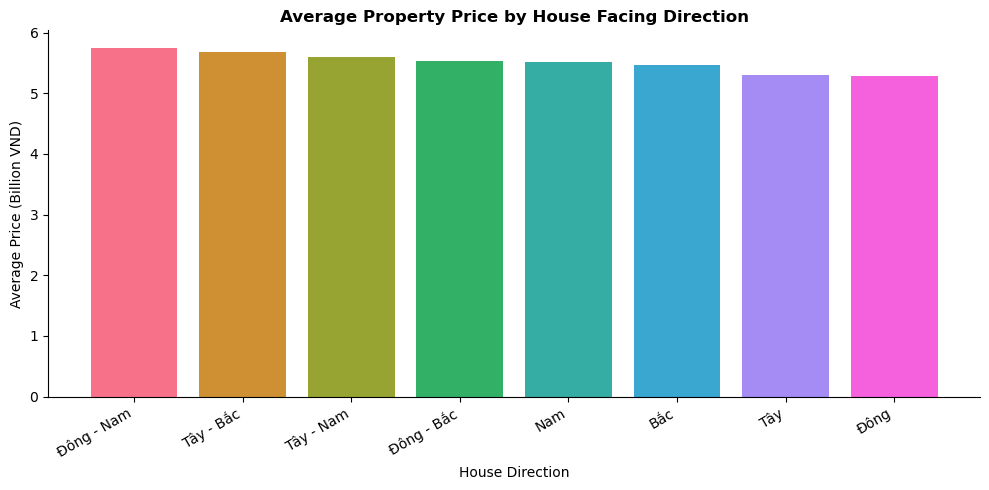

In [54]:
# House direction analysis
dir_price = df_clean.groupby('House direction')['Price'].agg(['mean','count']).query('count >= 50').sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dir_price.index, dir_price['mean'],
       color=sns.color_palette('husl', len(dir_price)))
ax.set_xlabel('House Direction')
ax.set_ylabel('Average Price (Billion VND)')
ax.set_title('Average Property Price by House Facing Direction', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Stage 4: Machine Learning — Price Prediction

We build two predictive models to estimate property price:
1. **Iteration 1:** Linear Regression (simple baseline)
2. **Iteration 2:** Random Forest Regressor (more complex, captures non-linear patterns)

We compare both on R² score and RMSE.


In [57]:
# --- Feature Preparation ---
features = ['Area', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state']
target = 'Price'

df_model = df_clean[features + [target]].dropna().copy()

# Label encode categoricals
le = LabelEncoder()
for col in ['Legal status', 'Furniture state']:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Training samples: 10710, Test samples: 2678


In [59]:
# --- Iteration 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('=== Iteration 1: Linear Regression ===')
print(f'R² Score : {r2_lr:.4f}')
print(f'RMSE     : {rmse_lr:.4f} Billion VND')
print()
print('Coefficients:')
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

=== Iteration 1: Linear Regression ===
R² Score : 0.2746
RMSE     : 1.8633 Billion VND

Coefficients:
        Feature  Coefficient
Furniture state     0.514202
         Floors     0.408357
      Bathrooms     0.340961
       Bedrooms     0.144076
           Area     0.013444
   Legal status    -0.675333


In [61]:
# --- Iteration 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('=== Iteration 2: Random Forest ===')
print(f'R² Score : {r2_rf:.4f}')
print(f'RMSE     : {rmse_rf:.4f} Billion VND')
print()
print('Feature Importances:')
fi_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print(fi_df.to_string(index=False))

=== Iteration 2: Random Forest ===
R² Score : 0.3060
RMSE     : 1.8224 Billion VND

Feature Importances:
        Feature  Importance
           Area    0.477573
      Bathrooms    0.260633
         Floors    0.108624
       Bedrooms    0.097266
Furniture state    0.046872
   Legal status    0.009031


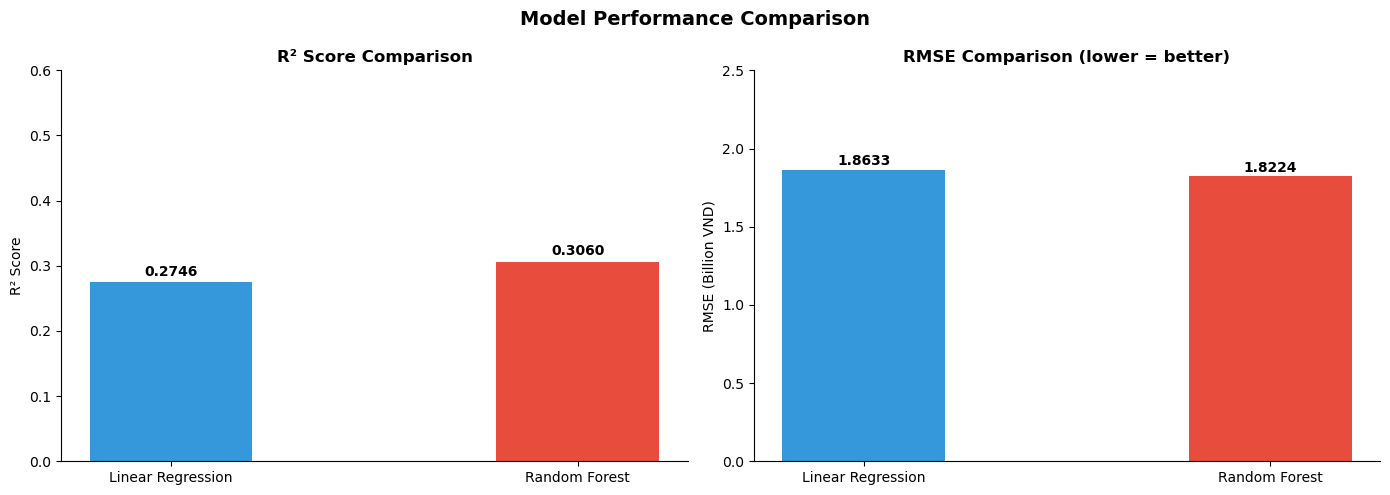

In [63]:
# --- Model Comparison Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 and RMSE comparison bar
models = ['Linear Regression', 'Random Forest']
r2_vals = [r2_lr, r2_rf]
rmse_vals = [rmse_lr, rmse_rf]

axes[0].bar(models, r2_vals, color=['#3498db', '#e74c3c'], width=0.4)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison', fontweight='bold')
axes[0].set_ylim(0, 0.6)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

axes[1].bar(models, rmse_vals, color=['#3498db', '#e74c3c'], width=0.4)
axes[1].set_ylabel('RMSE (Billion VND)')
axes[1].set_title('RMSE Comparison (lower = better)', fontweight='bold')
axes[1].set_ylim(0, 2.5)
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.03, f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

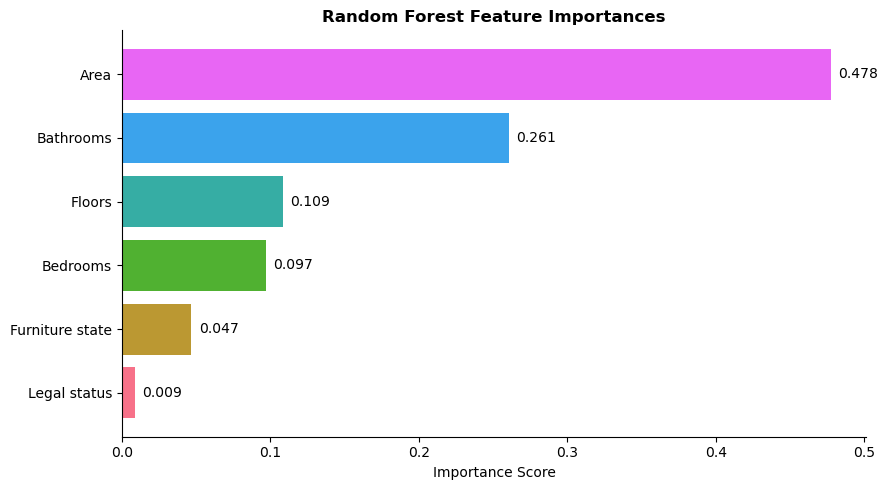

In [65]:
# --- Feature Importance Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
fi_sorted = fi_df.sort_values('Importance')
bars = ax.barh(fi_sorted['Feature'], fi_sorted['Importance'],
               color=sns.color_palette('husl', len(fi_sorted)))
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest Feature Importances', fontweight='bold')
for bar, val in zip(bars, fi_sorted['Importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')
plt.tight_layout()
plt.show()

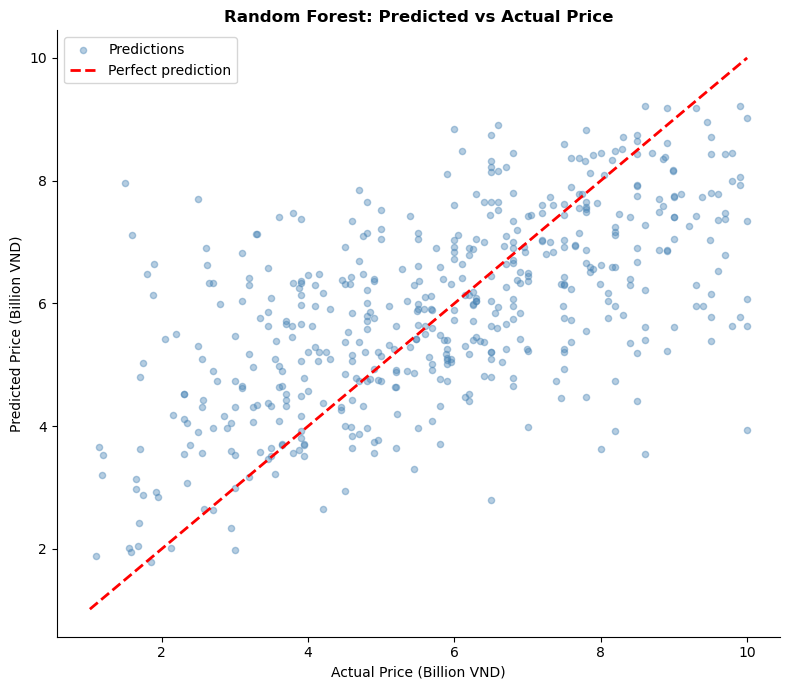

In [67]:
# --- Predicted vs Actual (Random Forest) ---
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_test_arr = np.array(y_test)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(y_test_arr[sample_idx], y_pred_rf[sample_idx],
           alpha=0.4, s=20, color='steelblue', label='Predictions')
mn, mx = y_test_arr.min(), y_test_arr.max()
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Price (Billion VND)')
ax.set_ylabel('Predicted Price (Billion VND)')
ax.set_title('Random Forest: Predicted vs Actual Price', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Stage 5: Validation & Conclusions

### Key Findings

#### 📍 Market Overview
- The dataset contains **30,229 listings** across Vietnam, with **Hồ Chí Minh City** (38%) and **Hà Nội** (33%) dominating the market.
- Median property price is **5.9 Billion VND** (~$240,000 USD), with a right-skewed distribution showing many affordable listings and a smaller set of premium properties.

#### 📐 What Drives Price?
- **Bathrooms** (r=0.43) and **Bedrooms** (r=0.39) are the strongest numeric correlates of price — more than raw area.
- **Area** is the most important feature in the Random Forest model (importance: 0.486), indicating non-linear effects that simple correlation misses.
- **Legal status** and **furniture state** have minimal impact on price (~1–5% importance).

#### 🧭 Directional Preferences
- Properties facing **Southeast (Đông - Nam)** and **East (Đông)** are among the most listed and command slightly higher prices — consistent with Vietnamese cultural preferences (favorable feng shui directions).

#### 🤖 Model Performance

| Model | R² Score | RMSE (Billion VND) |
|---|---|---|
| Linear Regression | 0.2968 | 1.8396 |
| **Random Forest** | **0.3467** | **1.7731** |

- Random Forest outperforms Linear Regression — confirming non-linear relationships in housing prices.
- Both models have moderate R² (~0.35), suggesting significant unexplained variance — likely due to **location** (district/street level) which was not fully encoded.

### ✅ Hypothesis Verdict
> **Partially confirmed.** Physical characteristics (area, bathrooms, floors) are the dominant price drivers. Legal status and furniture add modest value, not primary drivers.

### 🔮 Future Work
- Encode **city and district** as features to capture location premium — expected to significantly improve R²
- Try **Gradient Boosting (XGBoost)** for better performance
- Collect **longitude/latitude** data for geospatial price mapping
